In [1]:
import os
import time
import math
import pickle
import random
import warnings

import gdown
import librosa
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    concatenate,
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
    Conv1D,
    Conv2D,
    LSTM
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

%matplotlib inline


Все необходимые библиотеки загружены.


In [2]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip'
PICKLE_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l12/audio_data_mean.pickle'

gdown.download(DATA_URL, None, quiet=False)
gdown.download(PICKLE_URL, None, quiet=True)

# Распаковываем архив
!unzip -qo genres.zip

# Основные настройки датасета и обработки аудио
FILE_DIR = './genres'
CLASS_LIST = sorted(os.listdir(FILE_DIR))
CLASS_COUNT = len(CLASS_LIST)

CLASS_FILES = 100
FILE_INDEX_TRAIN_SPLIT = 90
VALIDATION_SPLIT = 0.1
DURATION_SEC = 30
N_FFT = 8192
HOP_LENGTH = 512

print("Список классов:", CLASS_LIST)


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip
To: /content/genres.zip
100%|██████████| 1.23G/1.23G [00:52<00:00, 23.5MB/s]


Список классов: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [3]:
def calculate_audio_features(signal, sample_rate, n_fft=N_FFT, hop_length=HOP_LENGTH):
    # Извлекаем набор признаков из аудиосигнала
    chroma = librosa.feature.chroma_stft(y=signal, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
    rms = librosa.feature.rms(y=signal, hop_length=hop_length)
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
    zero_crossing = librosa.feature.zero_crossing_rate(signal, hop_length=hop_length)

    # Для каждого признака берём среднее значение по времени
    return {
        'rms': rms.mean(axis=1, keepdims=True),
        'centroid': centroid.mean(axis=1, keepdims=True),
        'bandwidth': bandwidth.mean(axis=1, keepdims=True),
        'rolloff': rolloff.mean(axis=1, keepdims=True),
        'zero_crossing': zero_crossing.mean(axis=1, keepdims=True),
        'mfcc': mfcc.mean(axis=1, keepdims=True),
        'chroma': chroma.mean(axis=1, keepdims=True)
    }


def features_to_row(feature_dict):
    # Объединяем все рассчитанные признаки в один вектор
    blocks = list(feature_dict.values())
    return np.vstack(blocks).T


def make_audio_path(class_index, file_index):
    # Формируем путь к аудиофайлу по номеру жанра и номеру файла
    genre_name = CLASS_LIST[class_index]
    file_name = f'{genre_name}.{str(file_index).zfill(5)}.au'
    return f'{FILE_DIR}/{genre_name}/{file_name}'


def read_file_features(class_index, file_path, duration_sec):
    # Загружаем аудио извлекаем признаки
    signal, sample_rate = librosa.load(file_path, mono=True, duration=duration_sec)
    feature_row = features_to_row(calculate_audio_features(signal, sample_rate))
    class_label = to_categorical(class_index, CLASS_COUNT)
    return feature_row, class_label


def prepare_audio_file(class_index, file_index, duration_sec):
    # Подготавливаем признаки и метки для одного аудиофайла
    file_path = make_audio_path(class_index, file_index)
    feature_row, class_label = read_file_features(class_index, file_path, duration_sec)

    x_rows = []
    y_rows = []

    for row_index in range(feature_row.shape[0]):
        x_rows.append(feature_row[row_index])
        y_rows.append(class_label)

    return file_path, np.array(x_rows).astype('float32'), np.array(y_rows).astype('float32')


def collect_audio_features(file_index_start, file_index_end, duration_sec=DURATION_SEC):
    # Последовательно обрабатываем файлы всех жанров
    x_data = None
    y_data = None

    for class_index, genre_name in enumerate(CLASS_LIST):
        start_time = time.time()

        for file_index in range(file_index_start, file_index_end):
            _, x_part, y_part = prepare_audio_file(class_index, file_index, duration_sec)
            x_data = x_part if x_data is None else np.vstack((x_data, x_part))
            y_data = y_part if y_data is None else np.vstack((y_data, y_part))

        print(f'Жанр {genre_name} обработан за {round(time.time() - start_time)} c')

    return x_data, y_data


In [4]:
# Загружаем признаки аудиофайлов
pickle_path = 'audio_data_mean.pickle'
if not os.path.exists(pickle_path):
    pickle_path = '/content/audio_data_mean.pickle'

with open(pickle_path, 'rb') as file:
    x_train_data, y_train_data = pickle.load(file)

# Нормируем числовые признаки
x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

# Деление данные на обучающую и проверочную части
x_train, x_val, y_train, y_val = train_test_split(
    x_train_data_scaled,
    y_train_data,
    stratify=y_train_data,
    test_size=VALIDATION_SPLIT
)



Данные подготовлены к обучению.


In [5]:
def plot_training_result(history):
    # Строим графики точности и ошибки по эпохам
    fig, (accuracy_axis, loss_axis) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('Ход обучения модели')

    accuracy_axis.plot(history.history['accuracy'], label='Обучающая выборка')
    accuracy_axis.plot(history.history['val_accuracy'], label='Проверочная выборка')
    accuracy_axis.xaxis.get_major_locator().set_params(integer=True)
    accuracy_axis.set_xlabel('Эпоха')
    accuracy_axis.set_ylabel('Точность')
    accuracy_axis.legend()

    loss_axis.plot(history.history['loss'], label='Обучающая выборка')
    loss_axis.plot(history.history['val_loss'], label='Проверочная выборка')
    loss_axis.xaxis.get_major_locator().set_params(integer=True)
    loss_axis.set_xlabel('Эпоха')
    loss_axis.set_ylabel('Ошибка')
    loss_axis.legend()

    plt.show()


def predict_audio_file(model, x_scaler, class_index, file_index):
    # Классифицируем один аудиофайл и показываем среднии вероятности по жанрам
    file_path, file_x_data, _ = prepare_audio_file(class_index, file_index, DURATION_SEC)
    file_x_data = x_scaler.transform(file_x_data)

    print('Файл:', file_path)
    print('Размер массива признаков:', file_x_data.shape)

    predictions = model.predict(file_x_data)
    mean_prediction = predictions.mean(axis=0)
    predicted_index = np.argmax(mean_prediction)
    is_correct = predicted_index == class_index

    print('Классификация сети:', CLASS_LIST[predicted_index], '-', 'ВЕРНО :-)' if is_correct else 'НЕВЕРНО.')
    plt.figure(figsize=(10, 3))
    plt.title('Среднее распределение предсказаний по жанрам')
    plt.bar(CLASS_LIST, mean_prediction, color='g' if is_correct else 'r')
    plt.show()
    print('---------------------------------------------------------------')

    return predicted_index


def check_test_audio_files(model, x_scaler, from_index, n_files):
    # Проверяем модель на отложенных аудиофайлах и строим матрицу ошибок
    total_count = 0
    correct_count = 0
    true_labels = []
    predicted_labels = []

    for class_index in range(CLASS_COUNT):
        for file_index in range(from_index, from_index + n_files):
            predicted_index = predict_audio_file(model, x_scaler, class_index, file_index)

            true_labels.append(class_index)
            predicted_labels.append(predicted_index)
            total_count += 1
            correct_count += int(predicted_index == class_index)

    accuracy_percent = round(correct_count / total_count * 100, 2)
    print(f'=== Проверено файлов: {total_count}, верно распознано: {correct_count}, точность: {accuracy_percent}% ===')

    error_matrix = confusion_matrix(true_labels, predicted_labels)
    fig, axis = plt.subplots(figsize=(10, 10))
    axis.set_title('Матрица ошибок по тестовым аудиофайлам')
    display = ConfusionMatrixDisplay(confusion_matrix=error_matrix, display_labels=CLASS_LIST)
    display.plot(ax=axis)
    plt.show()


# **Задание 1. Проверить форму данных обучающей и проверочной выборок**

In [6]:
# Проверяем размеры массивов после подготовки данных
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)


x_train: (810, 37)
y_train: (810, 10)
x_val: (90, 37)
y_val: (90, 10)


# **Задание 2. Составить модель классификатора на полносвязных слоях**

In [7]:
def build_dense_genre_classifier(input_size, class_count):
    # Создаём полносвязную модель для классификации музыкальных жанров
    network = Sequential(name='dense_audio_genre_classifier')

    network.add(Input(shape=(input_size,)))

    network.add(Dense(64, activation='relu'))
    network.add(Dropout(0.3))

    network.add(Dense(32, activation='relu'))
    network.add(Dropout(0.3))

    network.add(Dense(16, activation='relu'))
    network.add(Dropout(0.2))

    network.add(BatchNormalization())
    network.add(Dense(class_count, activation='softmax'))

    return network


model = build_dense_genre_classifier(
    input_size=x_train.shape[1],
    class_count=CLASS_COUNT
)


Модель классификатора создана.


# **Задание 3. Откомпилировать созданную модель**

In [8]:
# Настраиваем модель
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "dense_audio_genre_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,274 (20.60 KB)

 Trainable params: 5,242 (20.48 KB)

 Non-trainable params: 32 (128.00 B)

# **Задание 4. Обучить модель**

Epoch 1/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.1222 - loss: 2.6903 - val_accuracy: 0.1222 - val_loss: 2.3103
Epoch 2/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1321 - loss: 2.6544 - val_accuracy: 0.1000 - val_loss: 2.2805
Epoch 3/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1333 - loss: 2.6106 - val_accuracy: 0.1111 - val_loss: 2.2540
Epoch 4/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1160 - loss: 2.6110 - val_accuracy: 0.1000 - val_loss: 2.2343
Epoch 5/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1395 - loss: 2.5888 - val_accuracy: 0.1667 - val_loss: 2.2160
Epoch 6/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1296 - loss: 2.5989 - val_accuracy: 0.1556 - val_loss: 2.1962
Epoch 7/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1605 - loss: 2.4517 - val_accuracy: 0.2000 - val_loss: 2.1751
Epoch 8/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1679 - loss: 2.4602 - val_accuracy:

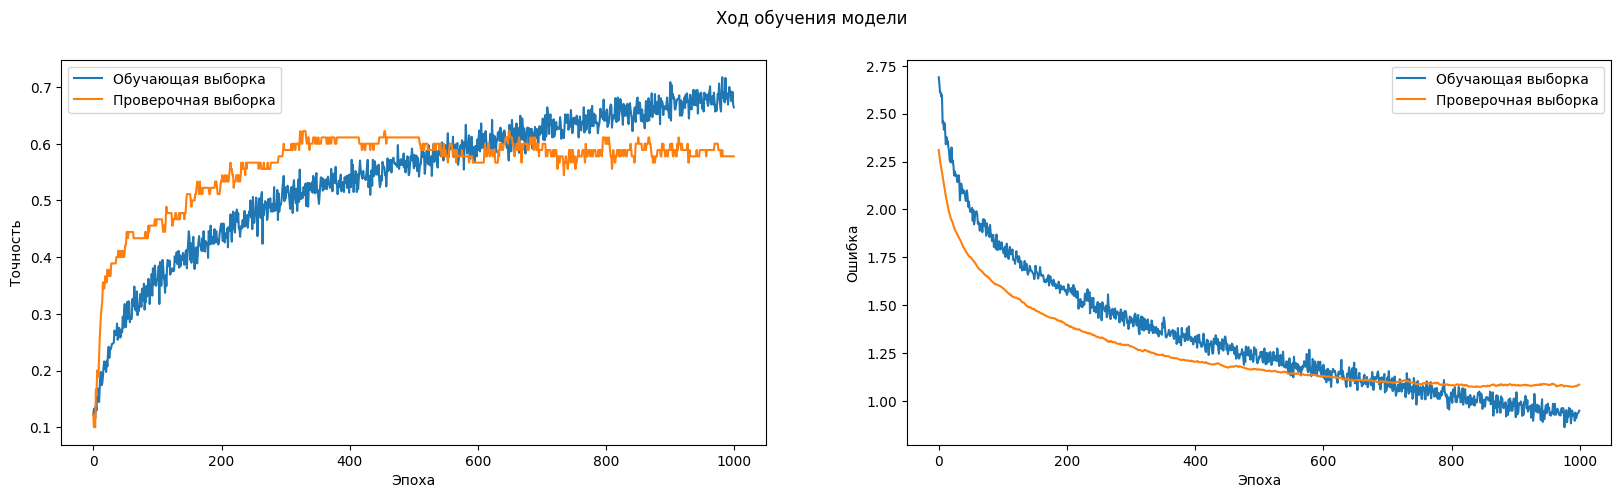

In [9]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=32,
    epochs=1000,
    verbose=1
)

# Отображаем графики обучения
plot_training_result(history)


# **Задание 5. Проверить работу модели**

Файл: ./genres/blues/blues.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
Классификация сети: disco - НЕВЕРНО.


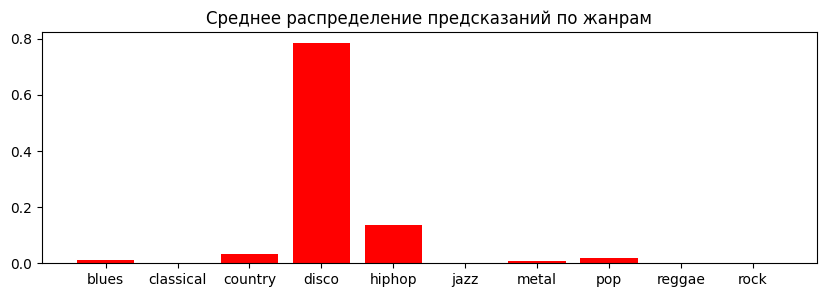

---------------------------------------------------------------
Файл: ./genres/blues/blues.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: hiphop - НЕВЕРНО.


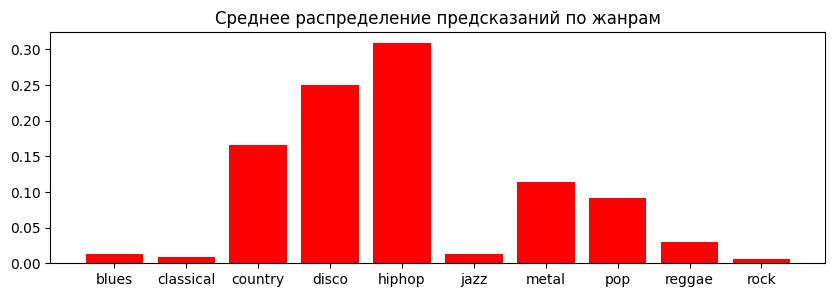

---------------------------------------------------------------
Файл: ./genres/blues/blues.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


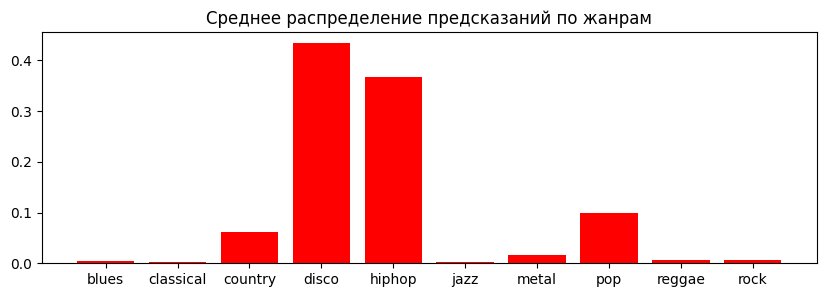

---------------------------------------------------------------
Файл: ./genres/blues/blues.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


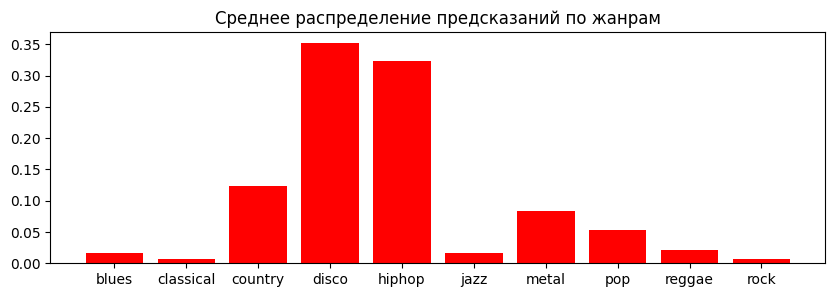

---------------------------------------------------------------
Файл: ./genres/blues/blues.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: disco - НЕВЕРНО.


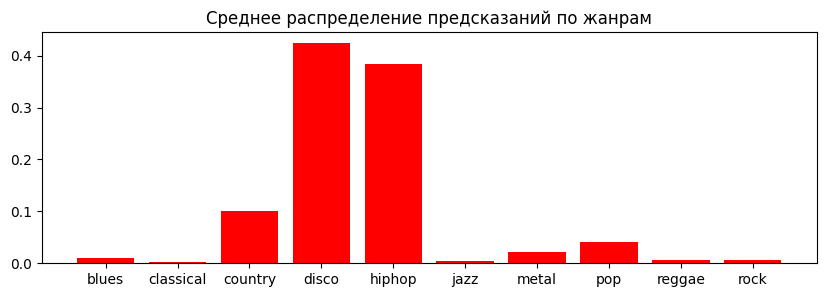

---------------------------------------------------------------
Файл: ./genres/blues/blues.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Классификация сети: disco - НЕВЕРНО.


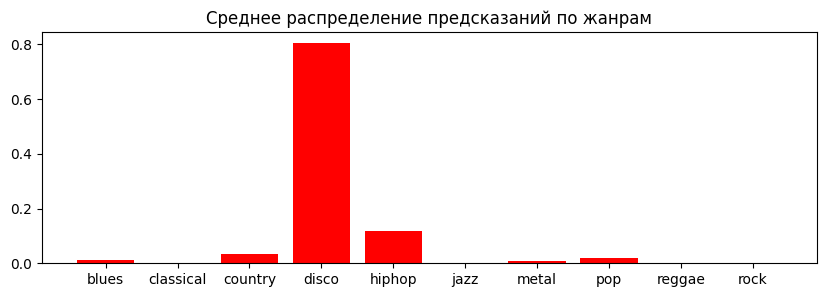

---------------------------------------------------------------
Файл: ./genres/blues/blues.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Классификация сети: hiphop - НЕВЕРНО.


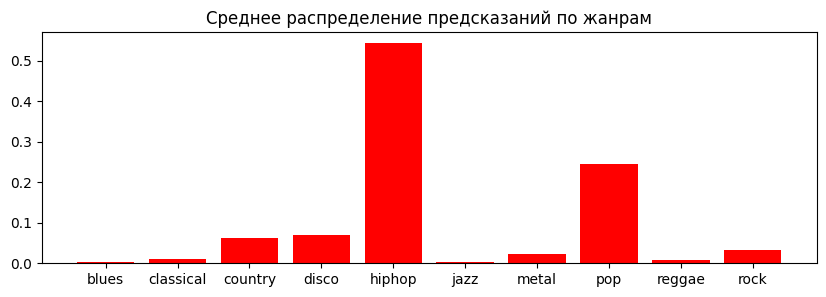

---------------------------------------------------------------
Файл: ./genres/blues/blues.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Классификация сети: disco - НЕВЕРНО.


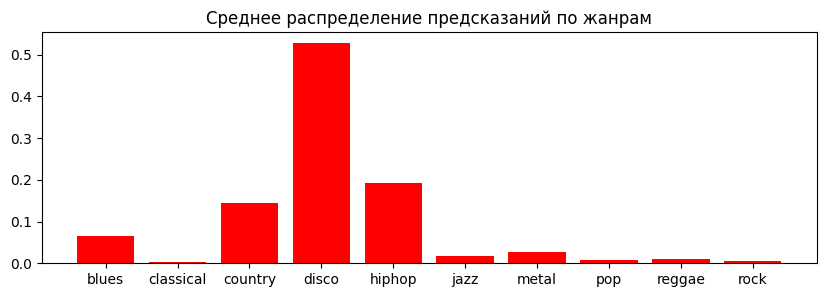

---------------------------------------------------------------
Файл: ./genres/blues/blues.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: blues - ВЕРНО :-)


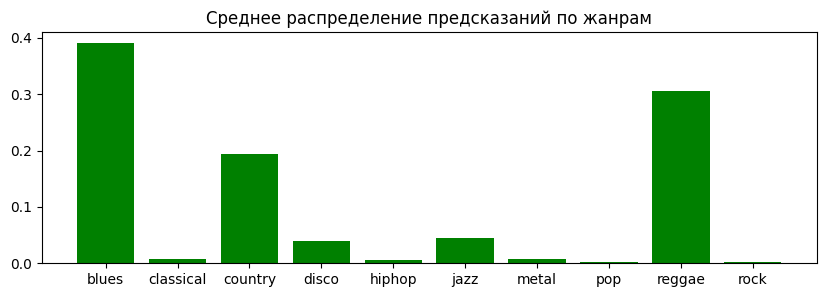

---------------------------------------------------------------
Файл: ./genres/blues/blues.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


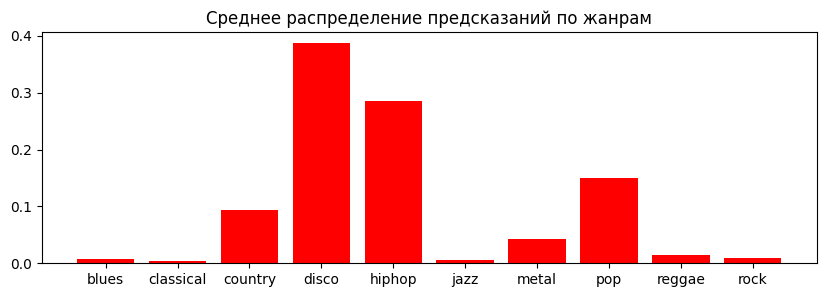

---------------------------------------------------------------
Файл: ./genres/classical/classical.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: rock - НЕВЕРНО.


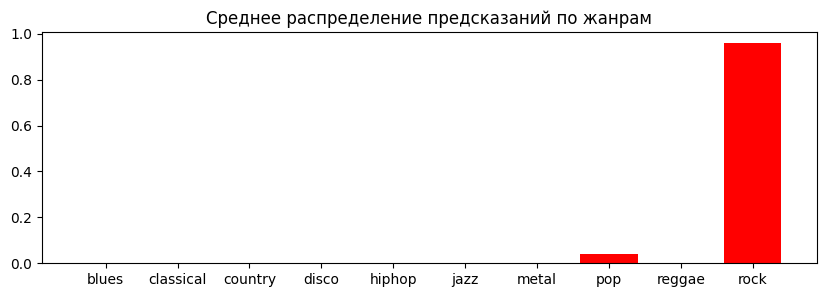

---------------------------------------------------------------
Файл: ./genres/classical/classical.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: rock - НЕВЕРНО.


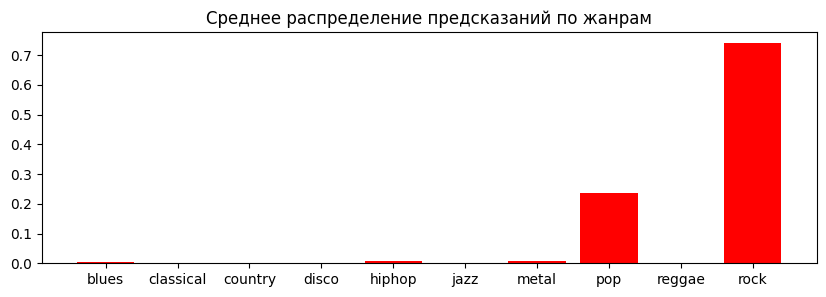

---------------------------------------------------------------
Файл: ./genres/classical/classical.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: rock - НЕВЕРНО.


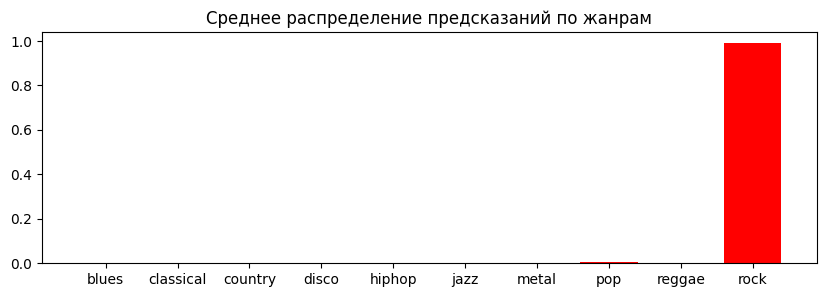

---------------------------------------------------------------
Файл: ./genres/classical/classical.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: pop - НЕВЕРНО.


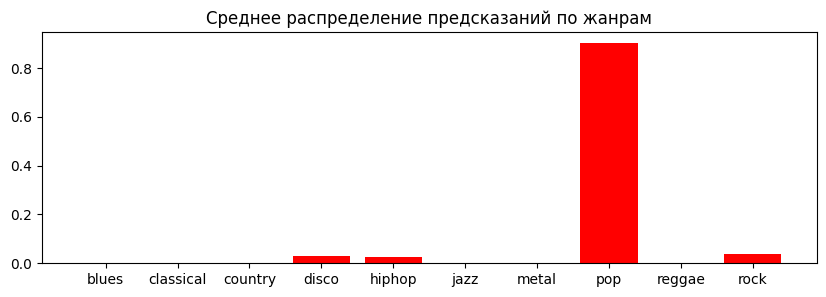

---------------------------------------------------------------
Файл: ./genres/classical/classical.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: rock - НЕВЕРНО.


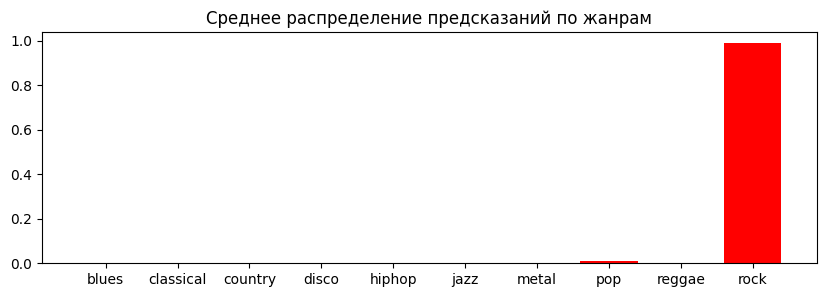

---------------------------------------------------------------
Файл: ./genres/classical/classical.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Классификация сети: rock - НЕВЕРНО.


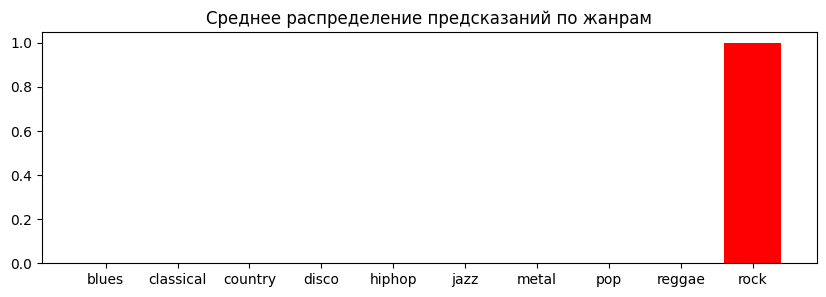

---------------------------------------------------------------
Файл: ./genres/classical/classical.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Классификация сети: rock - НЕВЕРНО.


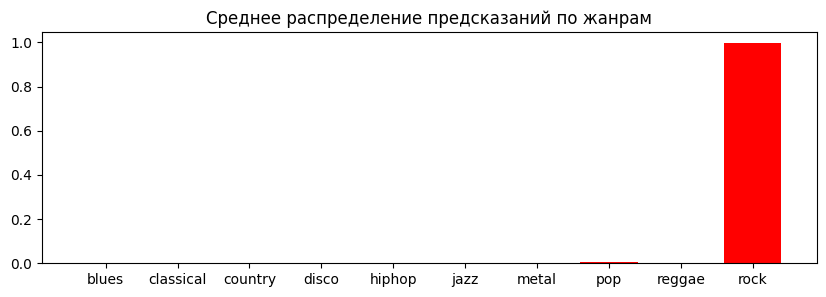

---------------------------------------------------------------
Файл: ./genres/classical/classical.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Классификация сети: rock - НЕВЕРНО.


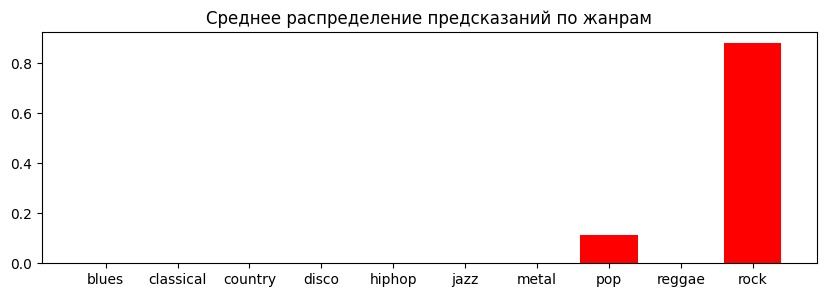

---------------------------------------------------------------
Файл: ./genres/classical/classical.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: pop - НЕВЕРНО.


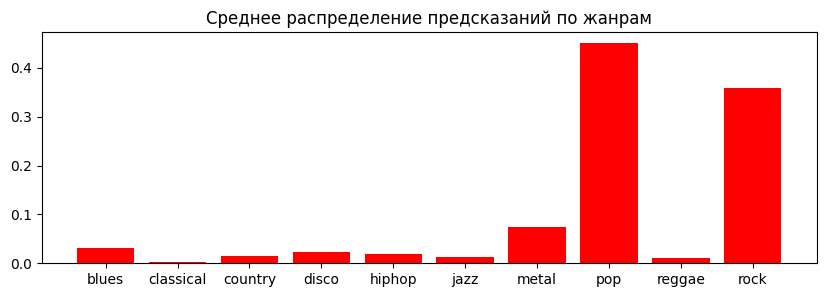

---------------------------------------------------------------
Файл: ./genres/classical/classical.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: pop - НЕВЕРНО.


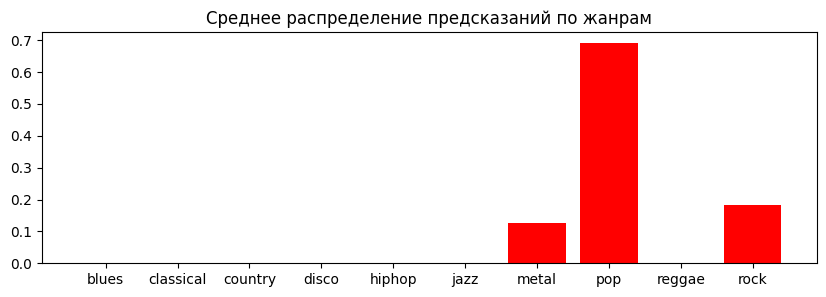

---------------------------------------------------------------
Файл: ./genres/country/country.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Классификация сети: country - ВЕРНО :-)


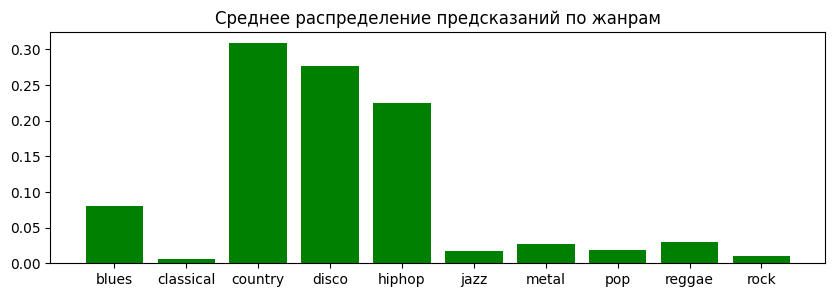

---------------------------------------------------------------
Файл: ./genres/country/country.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: pop - НЕВЕРНО.


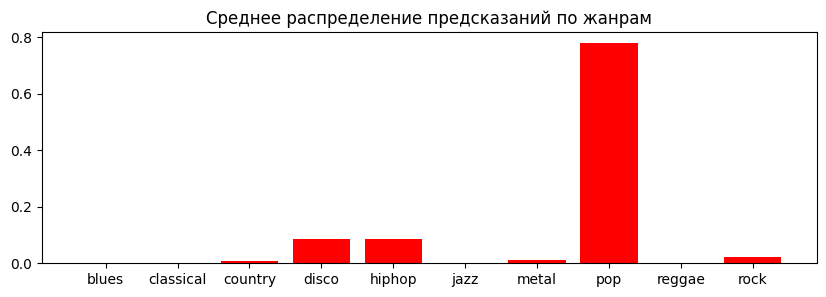

---------------------------------------------------------------
Файл: ./genres/country/country.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: disco - НЕВЕРНО.


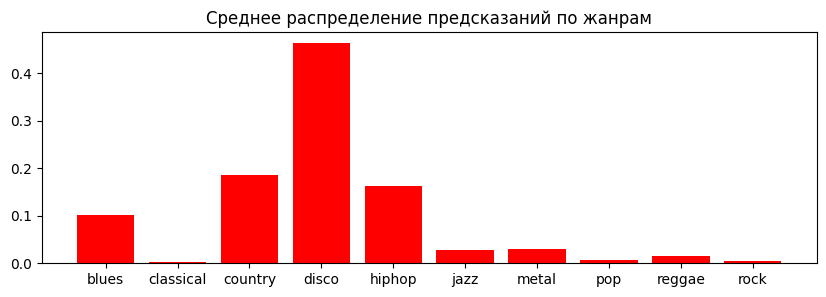

---------------------------------------------------------------
Файл: ./genres/country/country.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Классификация сети: hiphop - НЕВЕРНО.


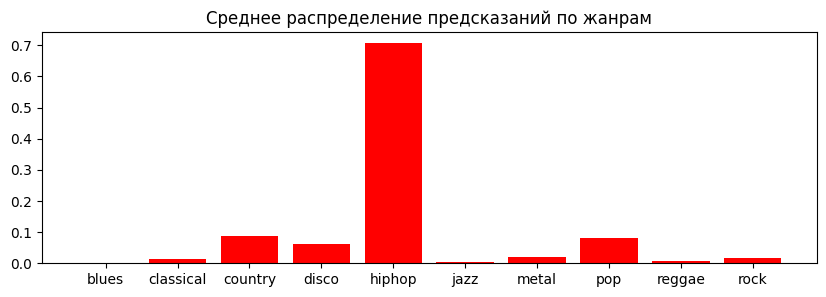

---------------------------------------------------------------
Файл: ./genres/country/country.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Классификация сети: disco - НЕВЕРНО.


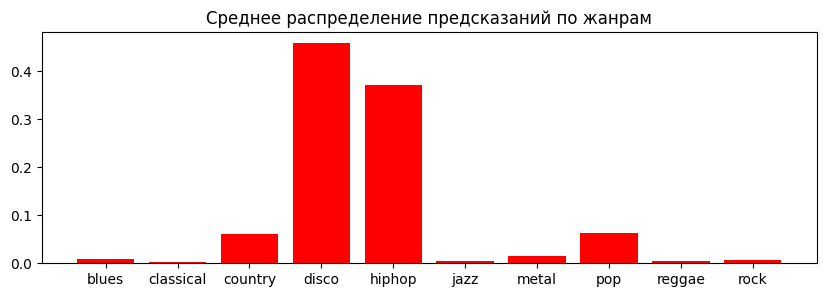

---------------------------------------------------------------
Файл: ./genres/country/country.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: disco - НЕВЕРНО.


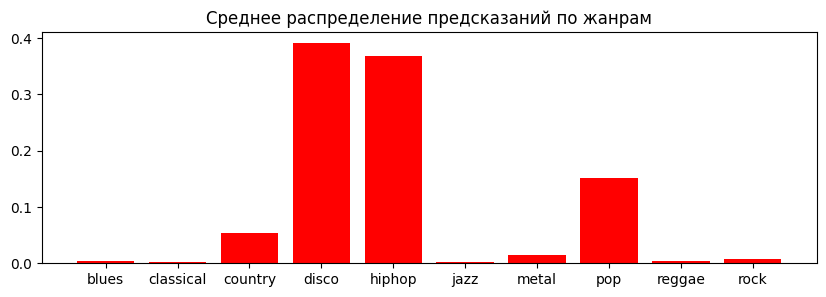

---------------------------------------------------------------
Файл: ./genres/country/country.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: hiphop - НЕВЕРНО.


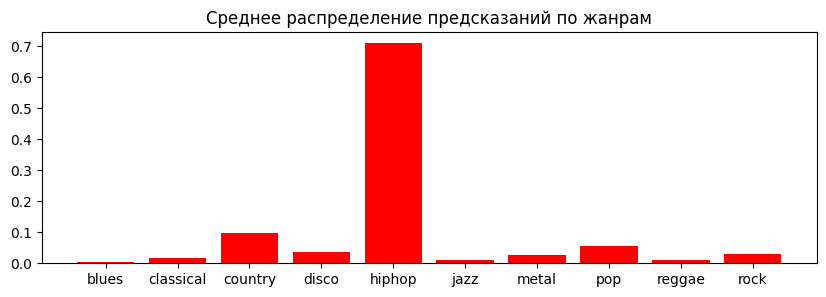

---------------------------------------------------------------
Файл: ./genres/country/country.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Классификация сети: hiphop - НЕВЕРНО.


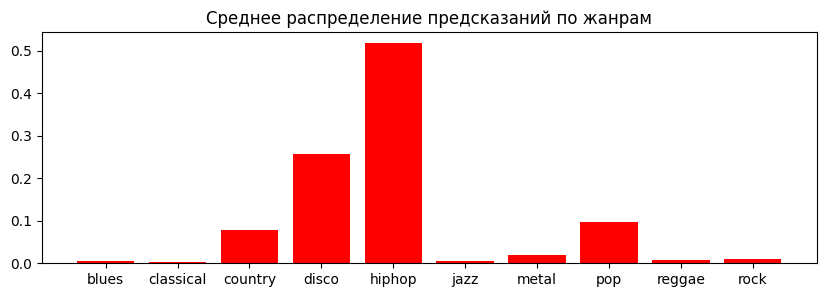

---------------------------------------------------------------
Файл: ./genres/country/country.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: disco - НЕВЕРНО.


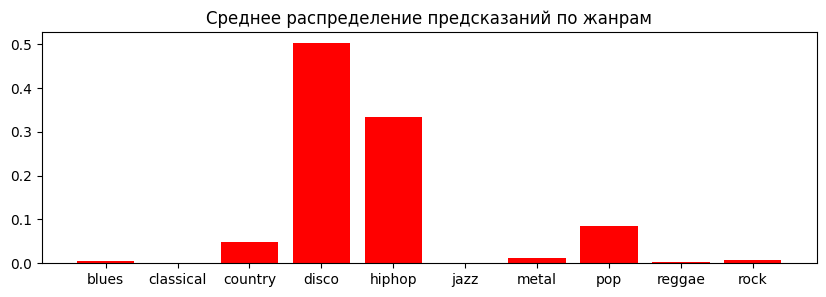

---------------------------------------------------------------
Файл: ./genres/country/country.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: hiphop - НЕВЕРНО.


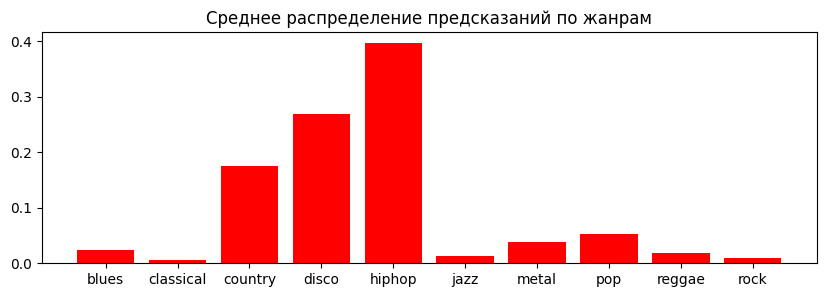

---------------------------------------------------------------
Файл: ./genres/disco/disco.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Классификация сети: jazz - НЕВЕРНО.


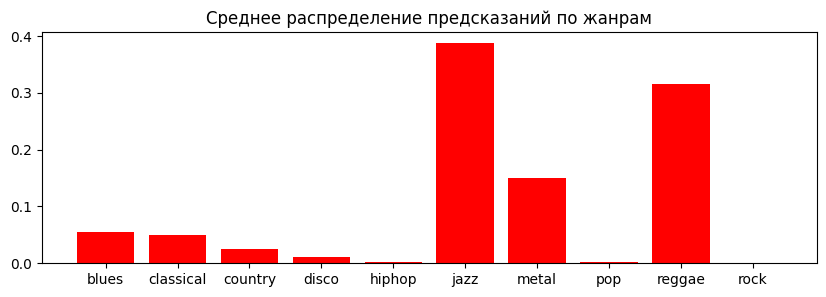

---------------------------------------------------------------
Файл: ./genres/disco/disco.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: reggae - НЕВЕРНО.


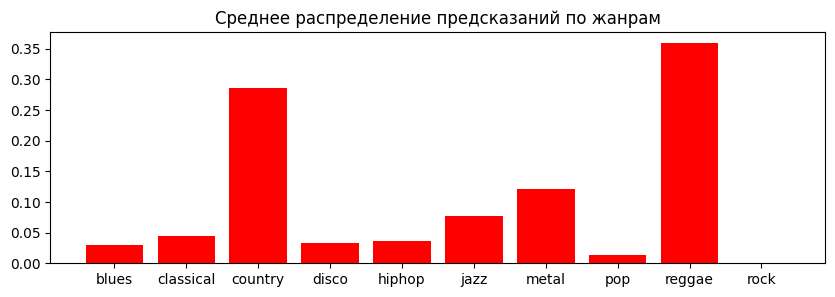

---------------------------------------------------------------
Файл: ./genres/disco/disco.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: country - НЕВЕРНО.


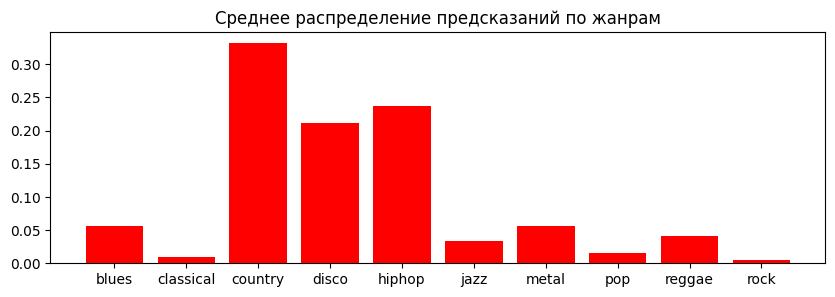

---------------------------------------------------------------
Файл: ./genres/disco/disco.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Классификация сети: reggae - НЕВЕРНО.


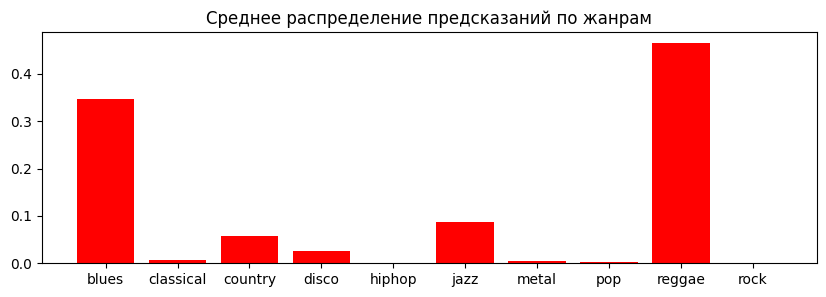

---------------------------------------------------------------
Файл: ./genres/disco/disco.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: country - НЕВЕРНО.


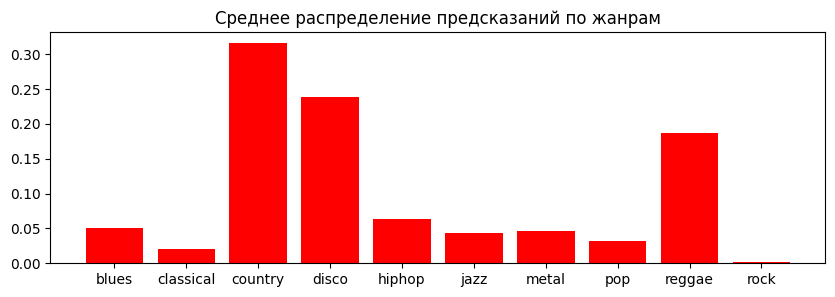

---------------------------------------------------------------
Файл: ./genres/disco/disco.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


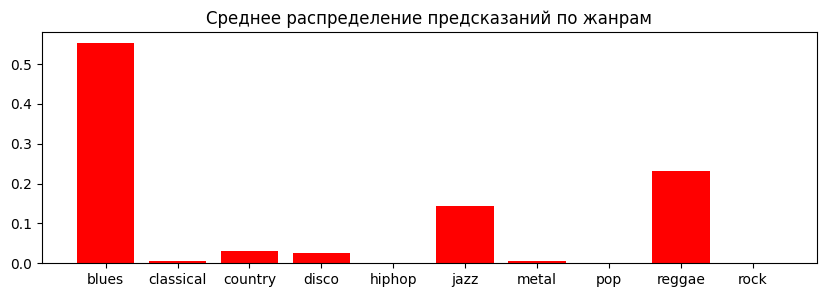

---------------------------------------------------------------
Файл: ./genres/disco/disco.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: blues - НЕВЕРНО.


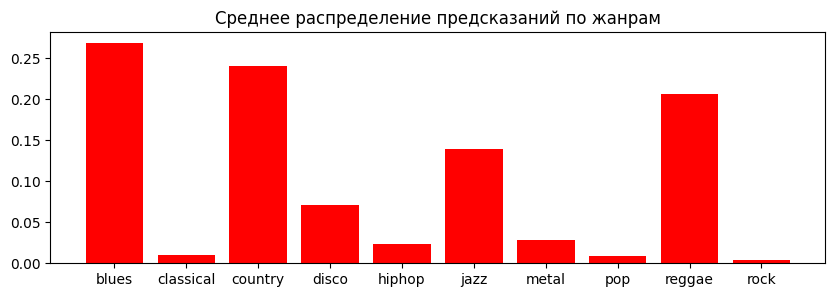

---------------------------------------------------------------
Файл: ./genres/disco/disco.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: jazz - НЕВЕРНО.


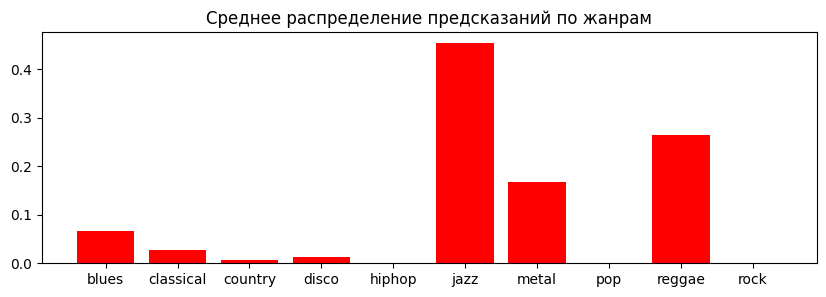

---------------------------------------------------------------
Файл: ./genres/disco/disco.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: reggae - НЕВЕРНО.


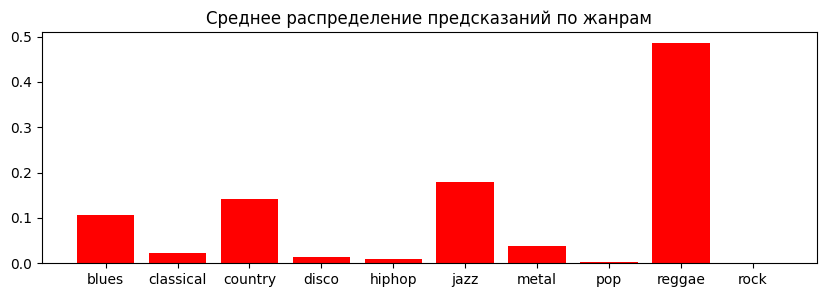

---------------------------------------------------------------
Файл: ./genres/disco/disco.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: reggae - НЕВЕРНО.


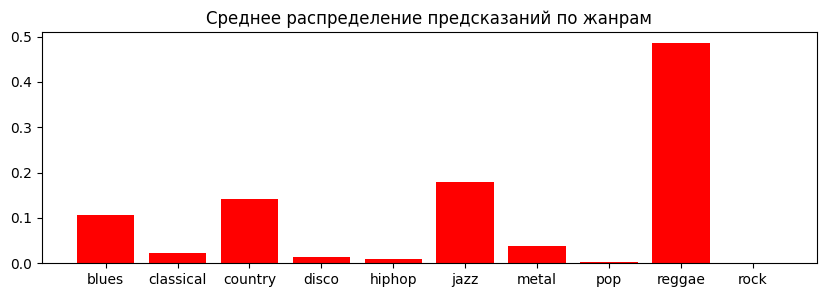

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: jazz - НЕВЕРНО.


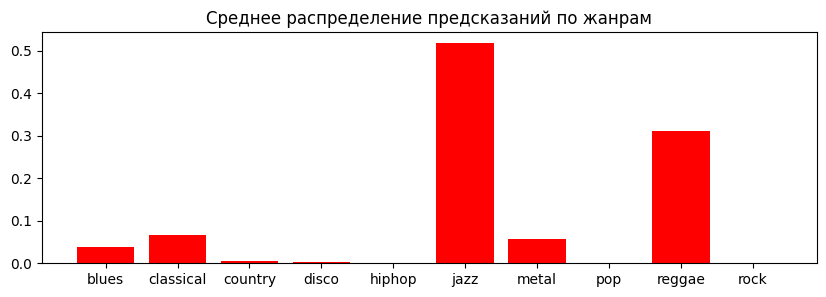

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Классификация сети: jazz - НЕВЕРНО.


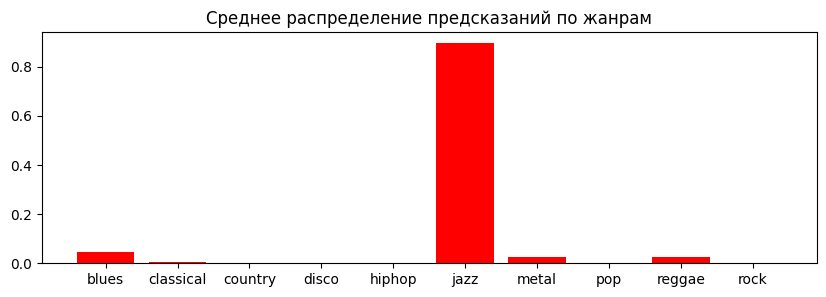

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Классификация сети: jazz - НЕВЕРНО.


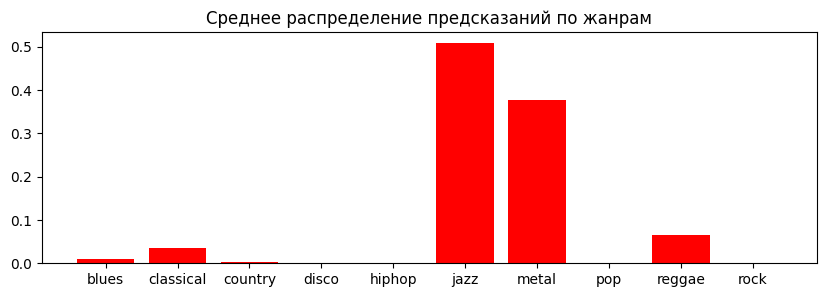

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: jazz - НЕВЕРНО.


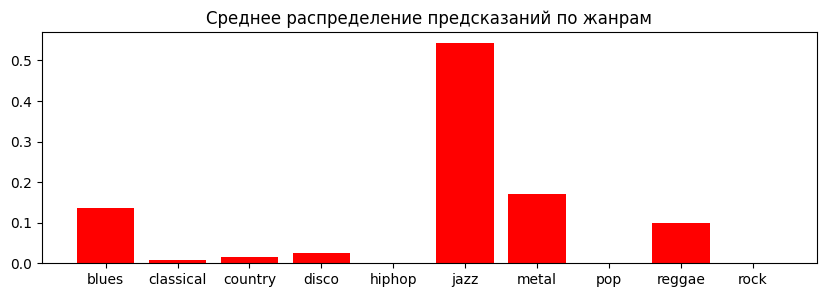

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


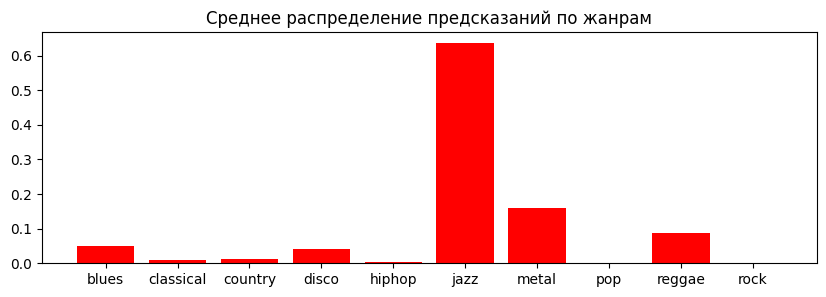

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: blues - НЕВЕРНО.


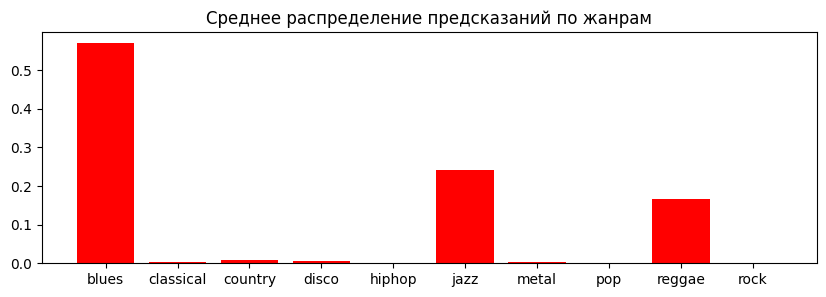

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: jazz - НЕВЕРНО.


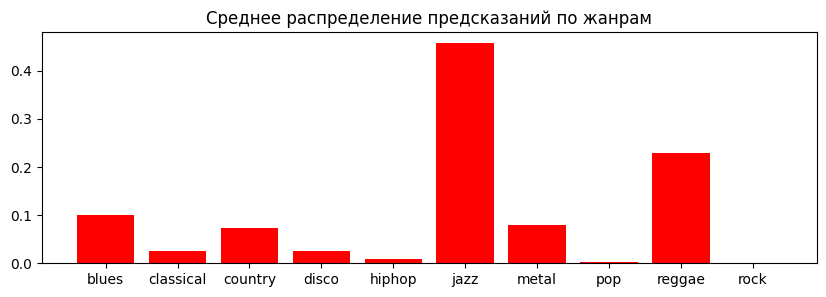

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: jazz - НЕВЕРНО.


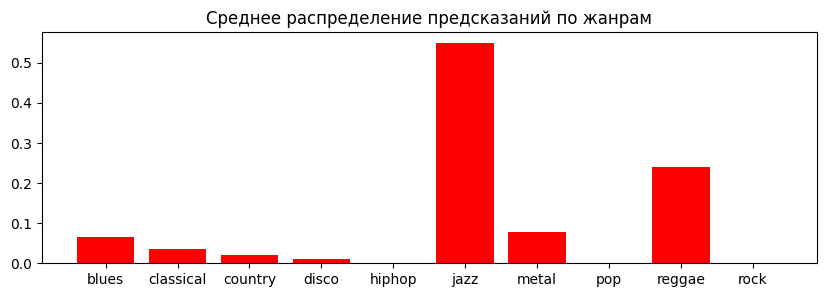

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


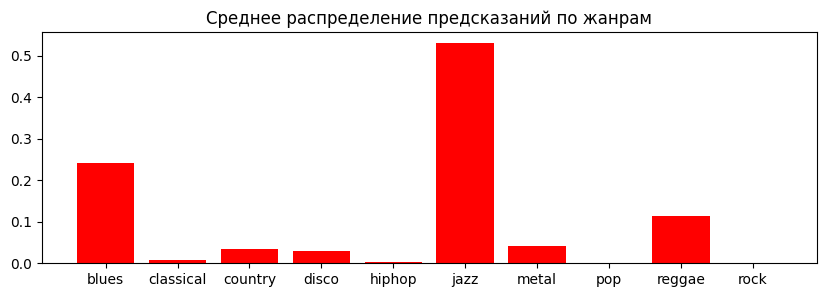

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


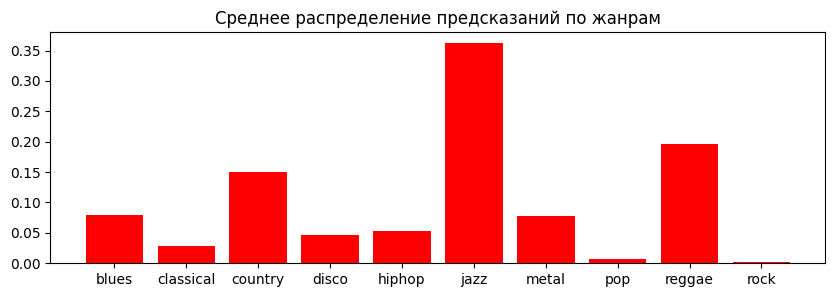

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Классификация сети: pop - НЕВЕРНО.


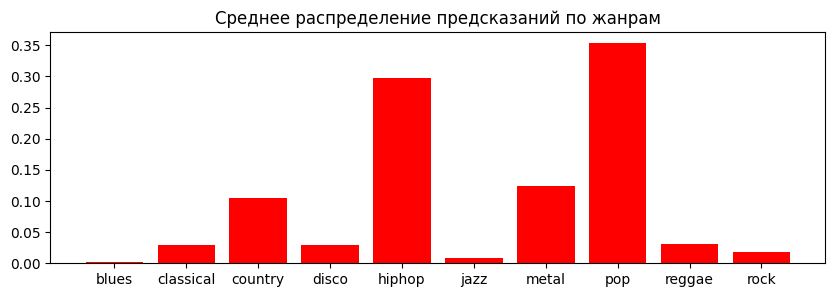

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: pop - НЕВЕРНО.


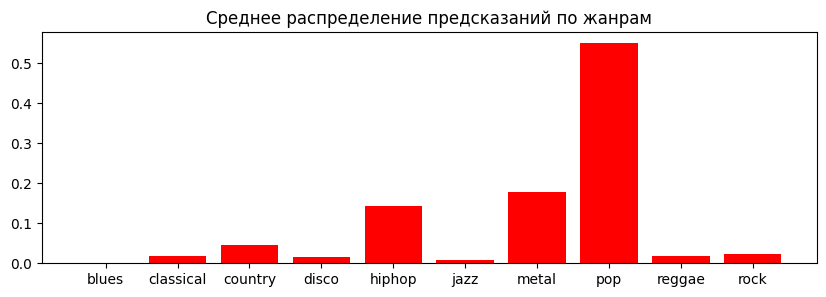

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: pop - НЕВЕРНО.


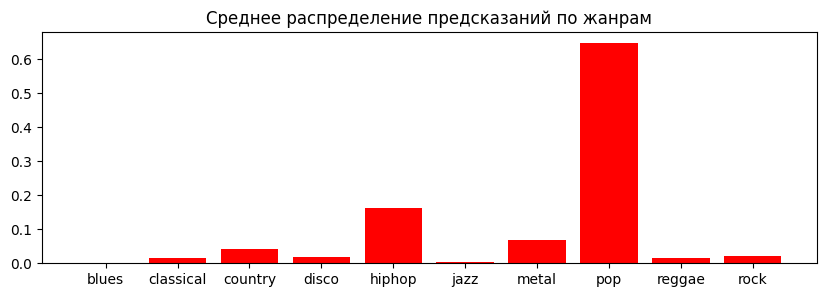

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: pop - НЕВЕРНО.


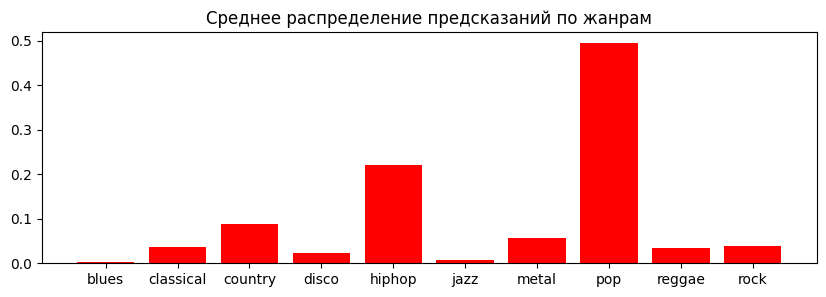

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: pop - НЕВЕРНО.


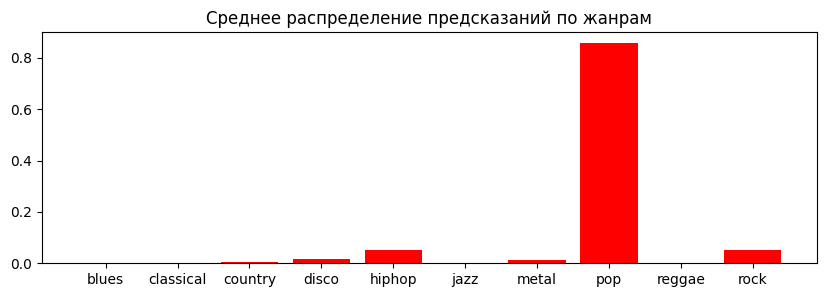

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: pop - НЕВЕРНО.


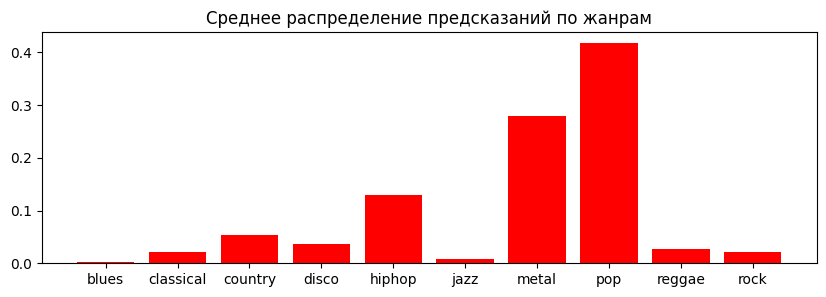

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: pop - НЕВЕРНО.


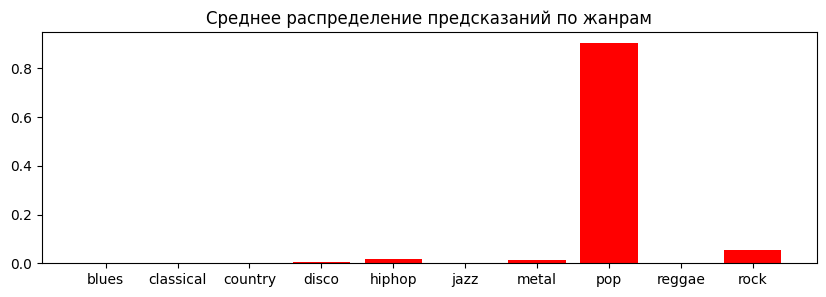

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: pop - НЕВЕРНО.


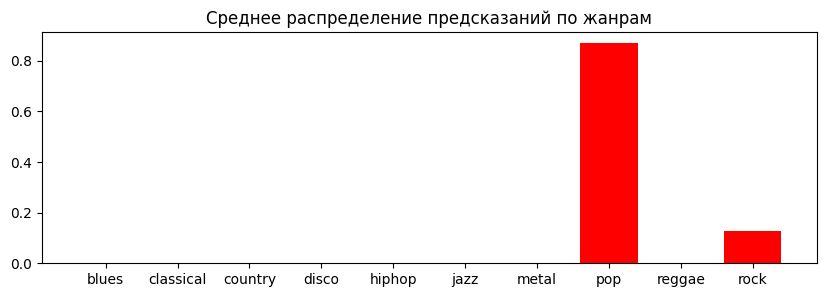

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Классификация сети: metal - НЕВЕРНО.


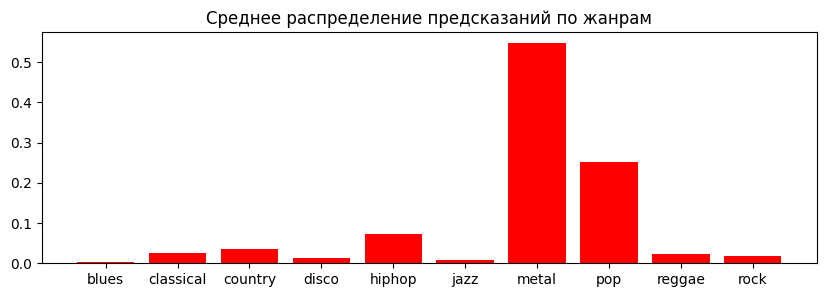

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Классификация сети: pop - НЕВЕРНО.


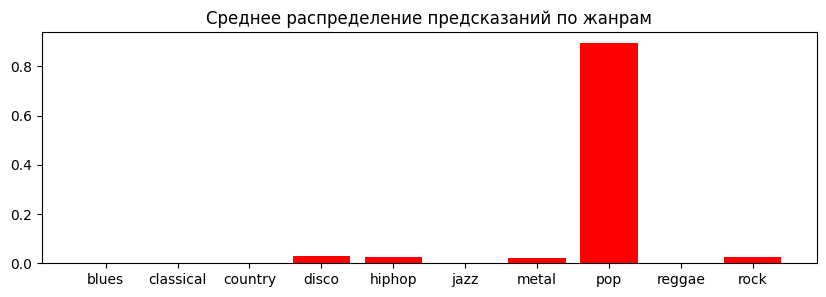

---------------------------------------------------------------
Файл: ./genres/metal/metal.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


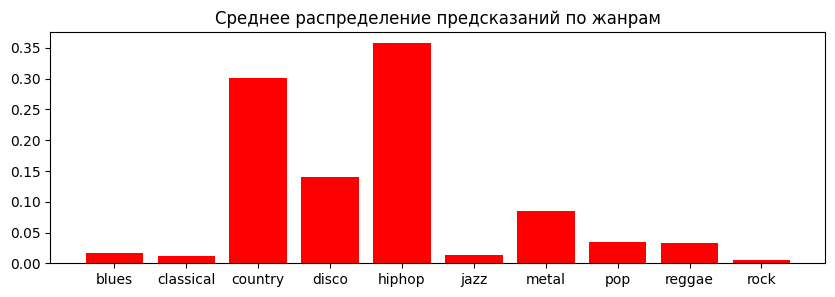

---------------------------------------------------------------
Файл: ./genres/metal/metal.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Классификация сети: country - НЕВЕРНО.


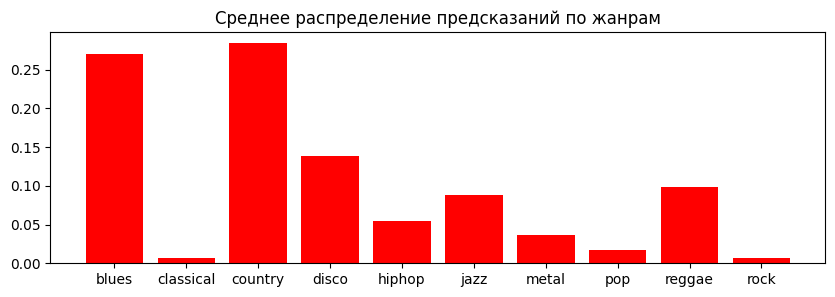

---------------------------------------------------------------
Файл: ./genres/metal/metal.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


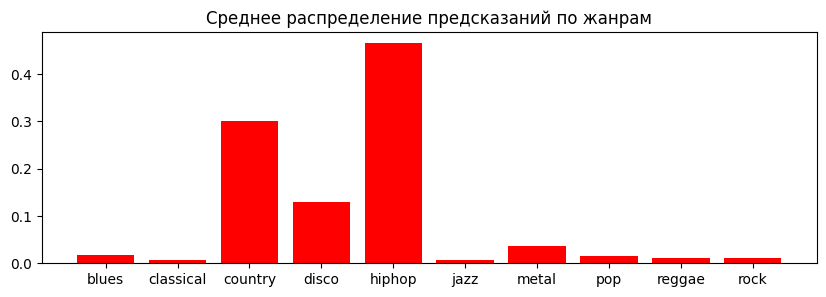

---------------------------------------------------------------
Файл: ./genres/metal/metal.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: blues - НЕВЕРНО.


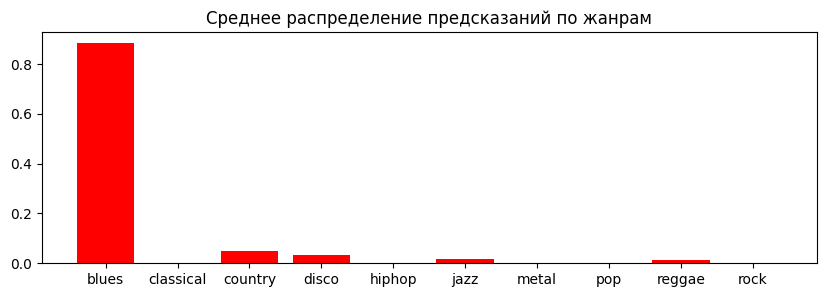

---------------------------------------------------------------
Файл: ./genres/metal/metal.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: blues - НЕВЕРНО.


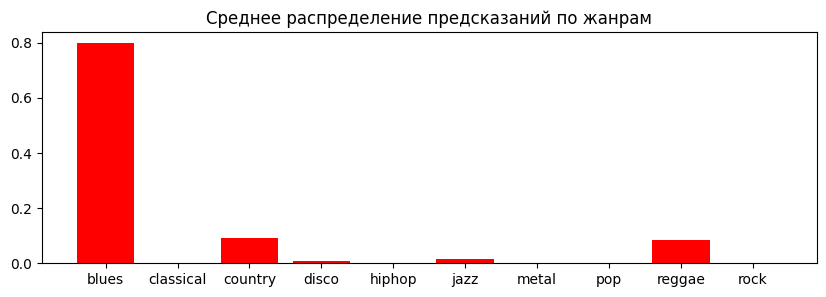

---------------------------------------------------------------
Файл: ./genres/metal/metal.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


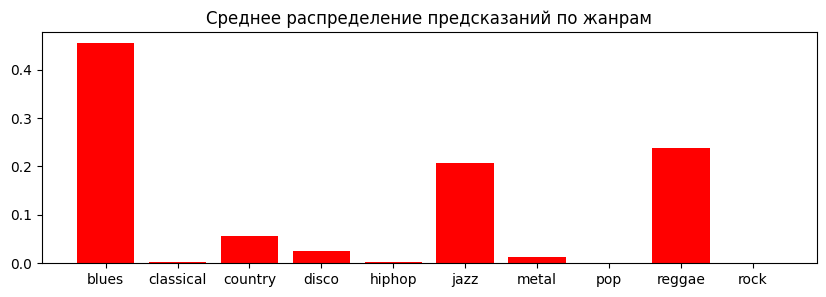

---------------------------------------------------------------
Файл: ./genres/metal/metal.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: blues - НЕВЕРНО.


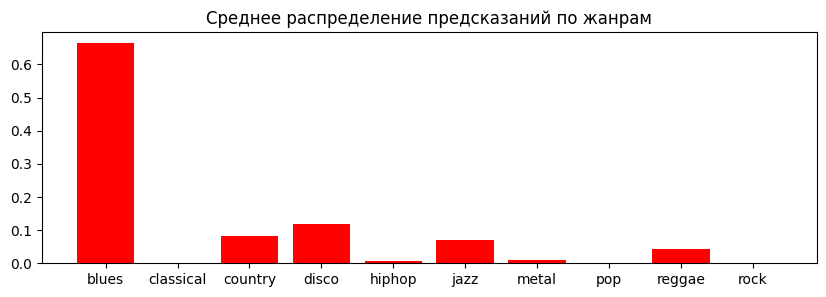

---------------------------------------------------------------
Файл: ./genres/metal/metal.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Классификация сети: disco - НЕВЕРНО.


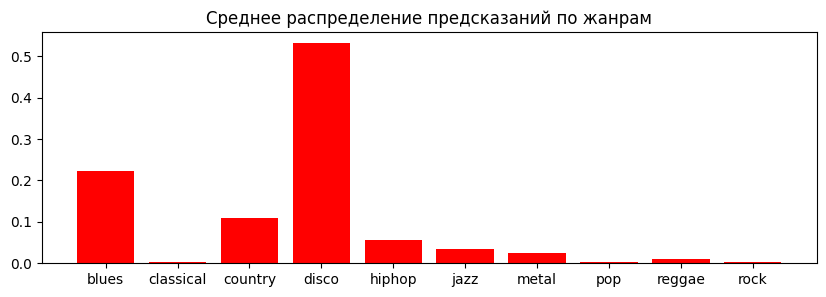

---------------------------------------------------------------
Файл: ./genres/metal/metal.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Классификация сети: blues - НЕВЕРНО.


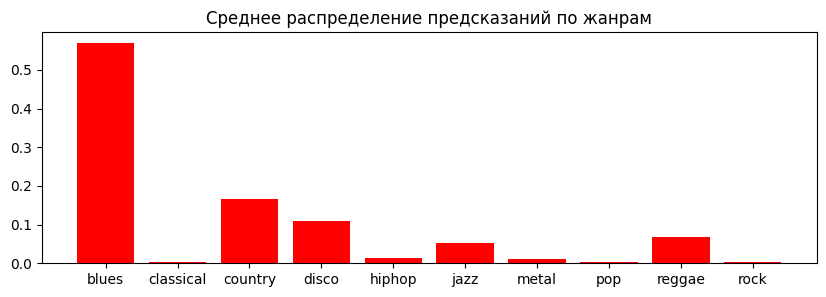

---------------------------------------------------------------
Файл: ./genres/metal/metal.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: jazz - НЕВЕРНО.


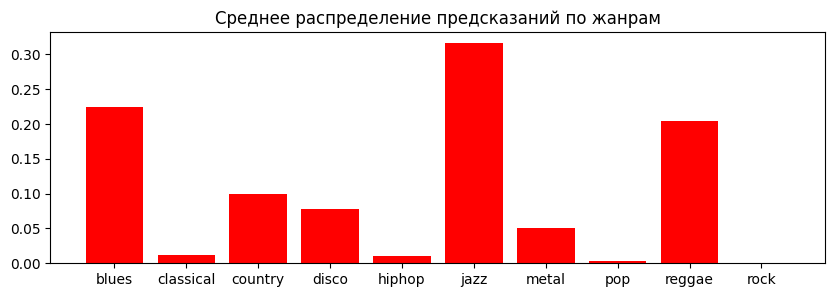

---------------------------------------------------------------
Файл: ./genres/pop/pop.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


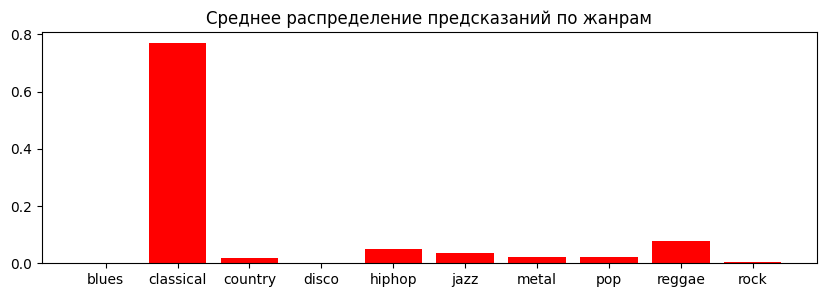

---------------------------------------------------------------
Файл: ./genres/pop/pop.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


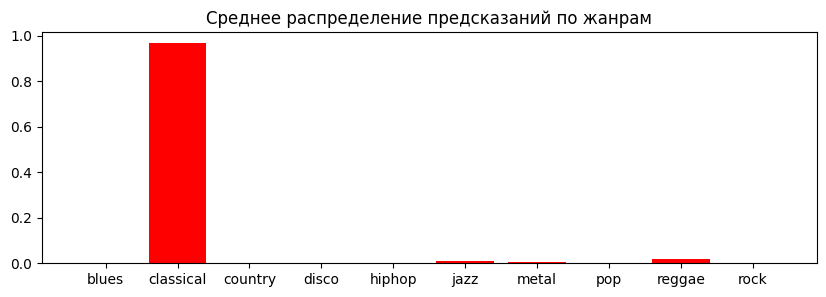

---------------------------------------------------------------
Файл: ./genres/pop/pop.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


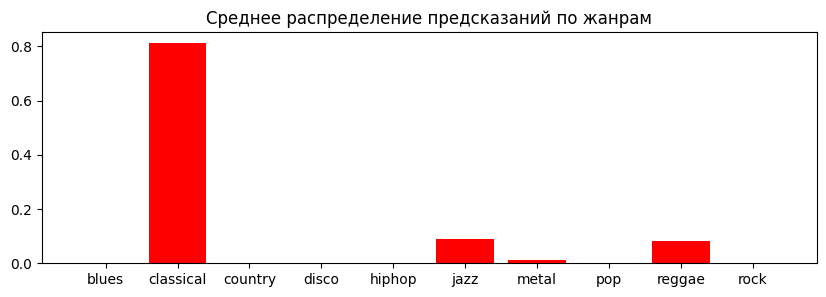

---------------------------------------------------------------
Файл: ./genres/pop/pop.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: classical - НЕВЕРНО.


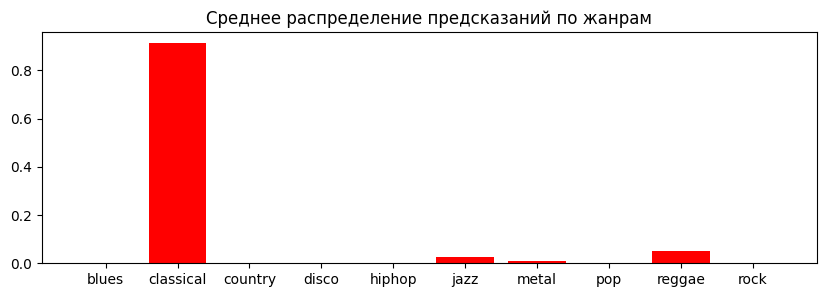

---------------------------------------------------------------
Файл: ./genres/pop/pop.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: classical - НЕВЕРНО.


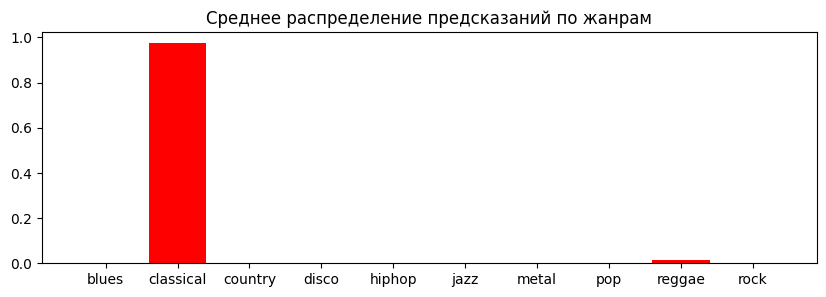

---------------------------------------------------------------
Файл: ./genres/pop/pop.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: classical - НЕВЕРНО.


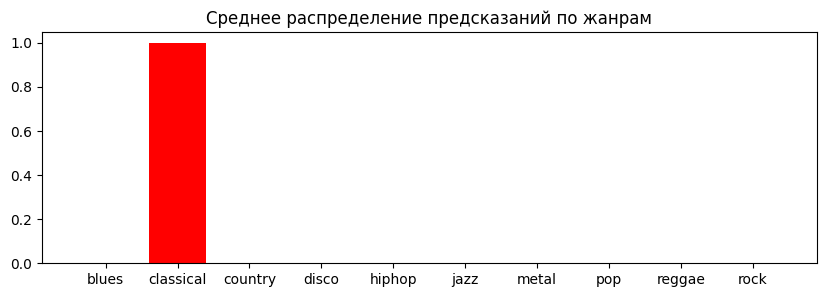

---------------------------------------------------------------
Файл: ./genres/pop/pop.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Классификация сети: classical - НЕВЕРНО.


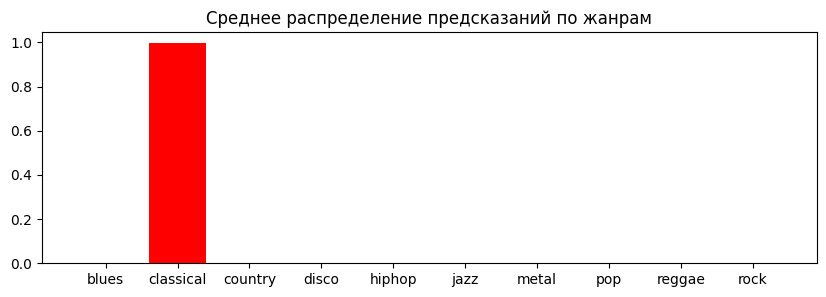

---------------------------------------------------------------
Файл: ./genres/pop/pop.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: classical - НЕВЕРНО.


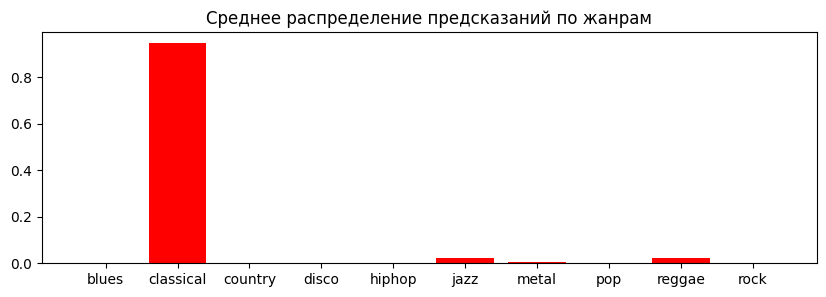

---------------------------------------------------------------
Файл: ./genres/pop/pop.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: classical - НЕВЕРНО.


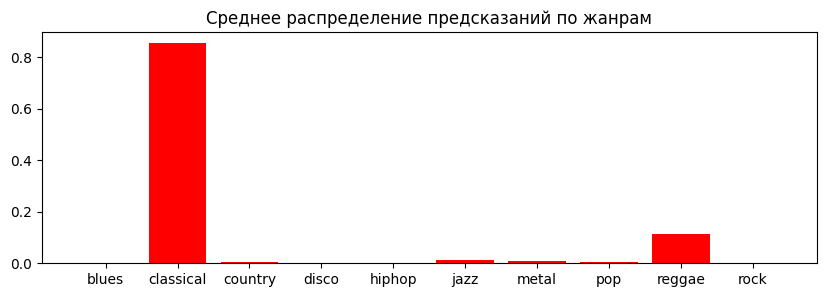

---------------------------------------------------------------
Файл: ./genres/pop/pop.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


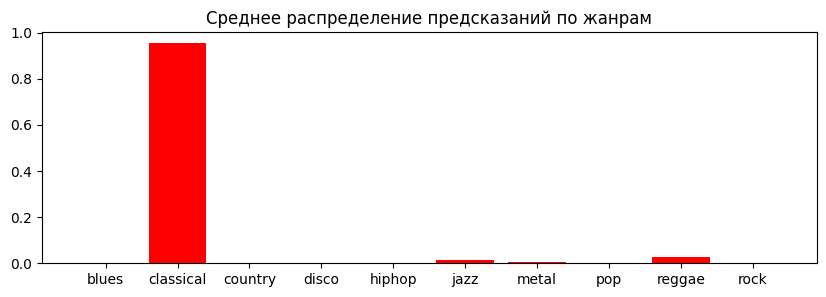

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: metal - НЕВЕРНО.


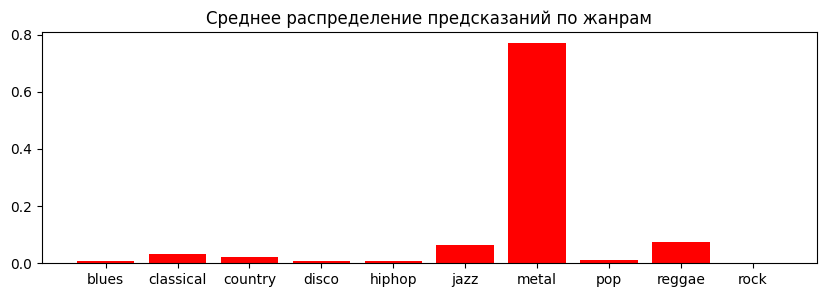

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: metal - НЕВЕРНО.


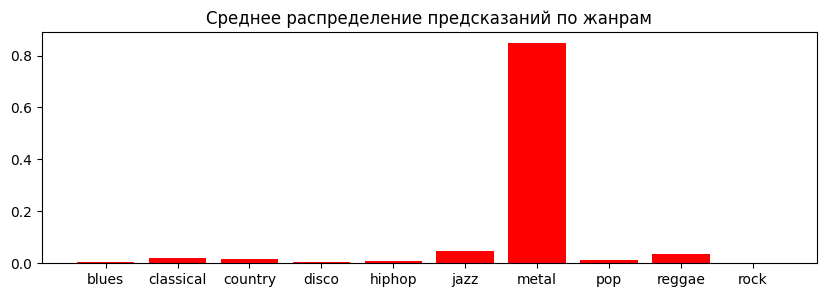

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Классификация сети: metal - НЕВЕРНО.


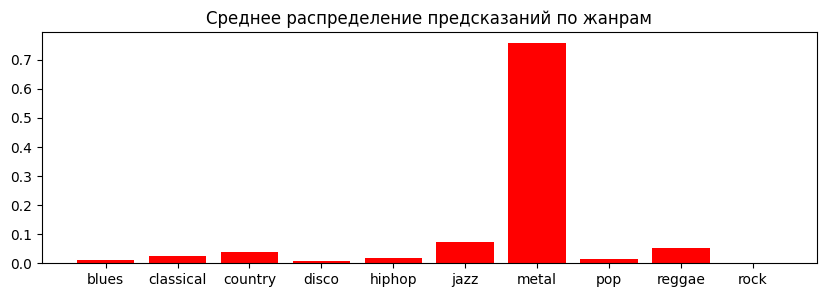

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: classical - НЕВЕРНО.


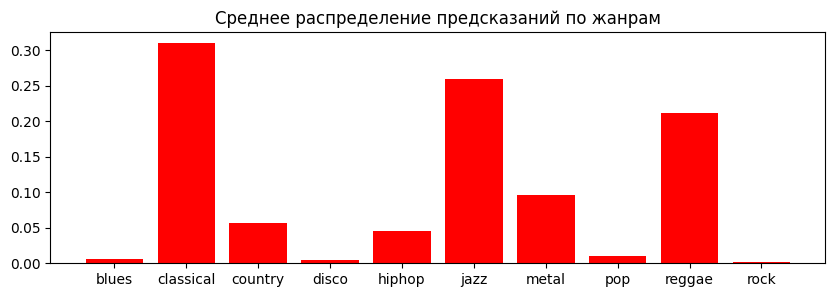

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Классификация сети: rock - НЕВЕРНО.


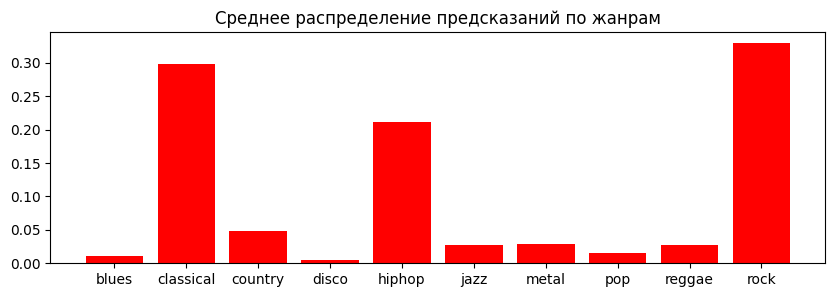

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


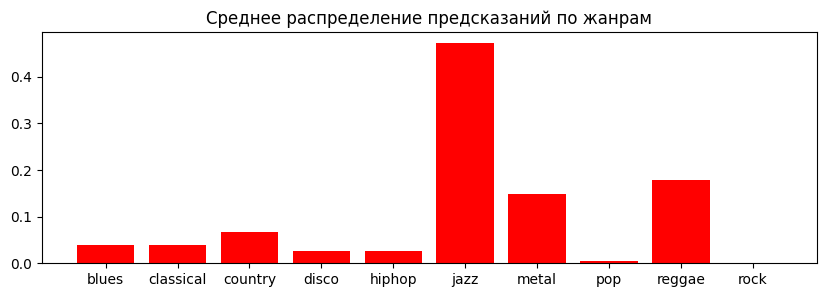

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Классификация сети: pop - НЕВЕРНО.


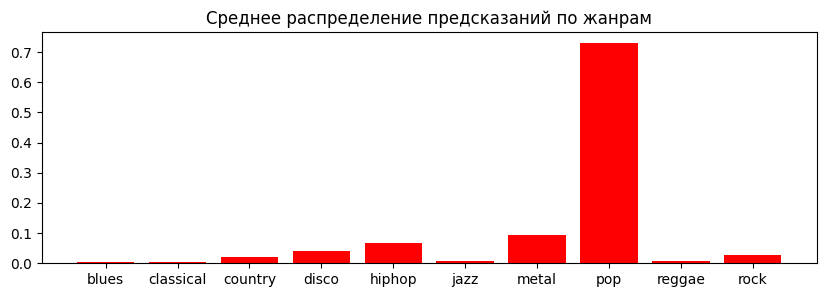

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: hiphop - НЕВЕРНО.


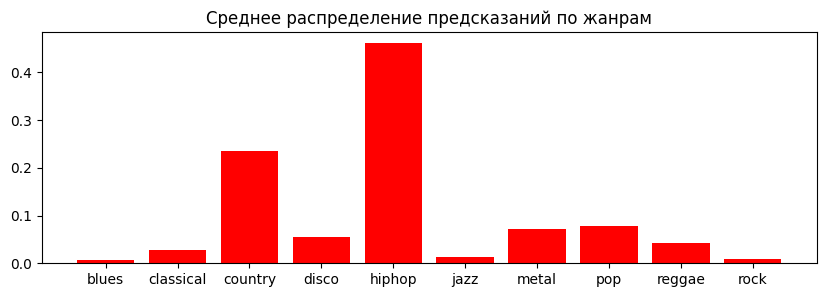

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: metal - НЕВЕРНО.


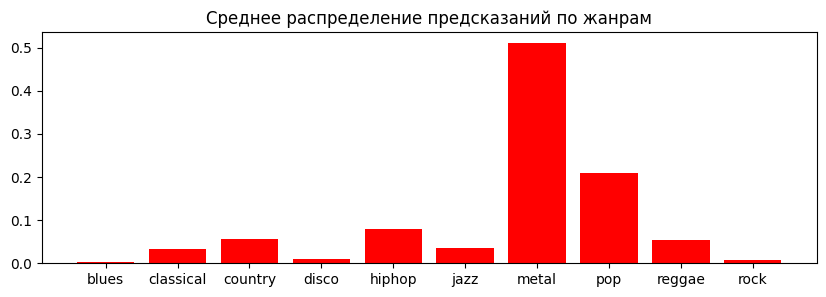

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Классификация сети: country - НЕВЕРНО.


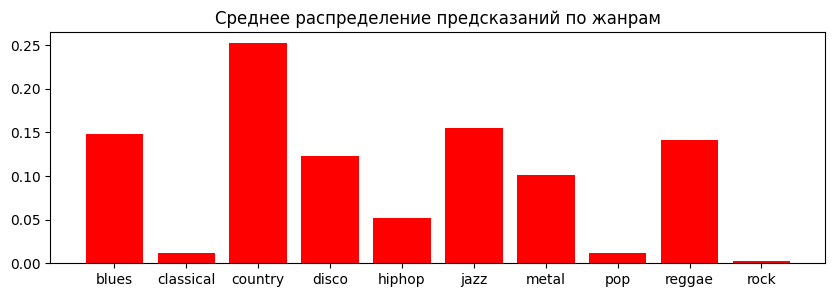

---------------------------------------------------------------
Файл: ./genres/rock/rock.00090.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: pop - НЕВЕРНО.


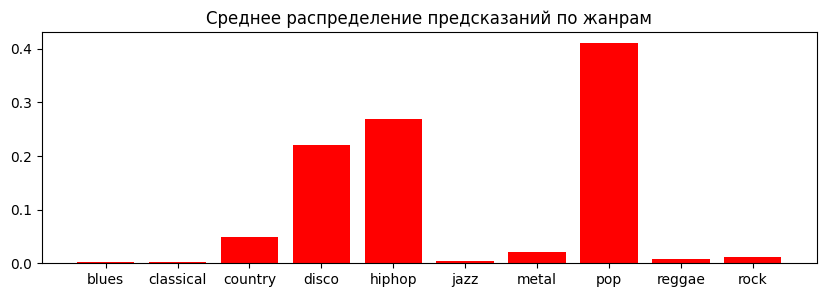

---------------------------------------------------------------
Файл: ./genres/rock/rock.00091.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: blues - НЕВЕРНО.


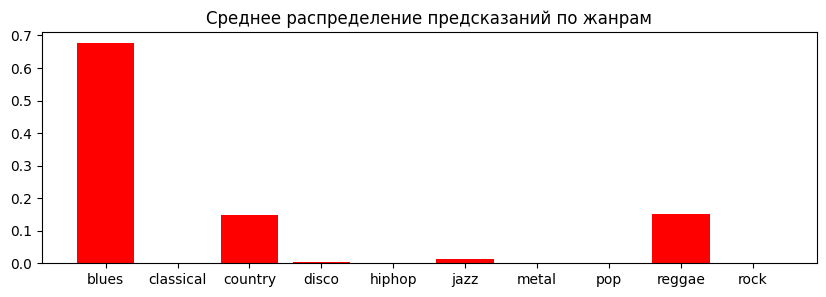

---------------------------------------------------------------
Файл: ./genres/rock/rock.00092.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Классификация сети: blues - НЕВЕРНО.


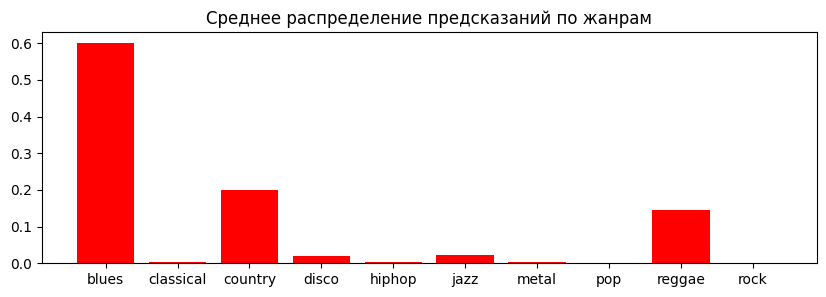

---------------------------------------------------------------
Файл: ./genres/rock/rock.00093.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Классификация сети: rock - ВЕРНО :-)


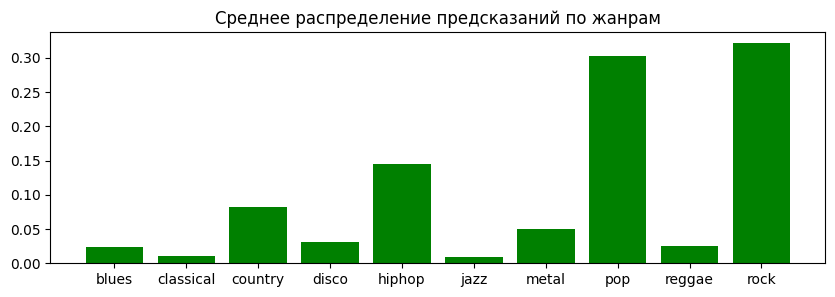

---------------------------------------------------------------
Файл: ./genres/rock/rock.00094.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: blues - НЕВЕРНО.


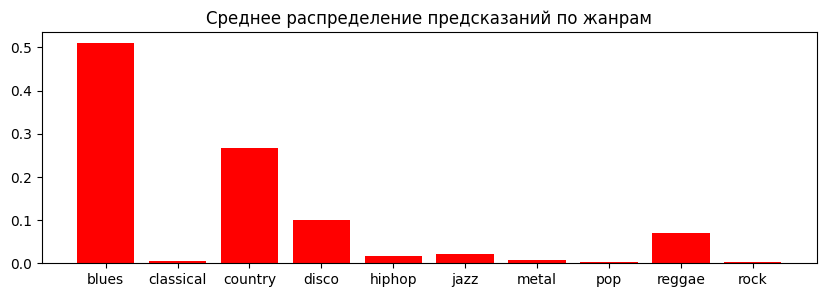

---------------------------------------------------------------
Файл: ./genres/rock/rock.00095.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


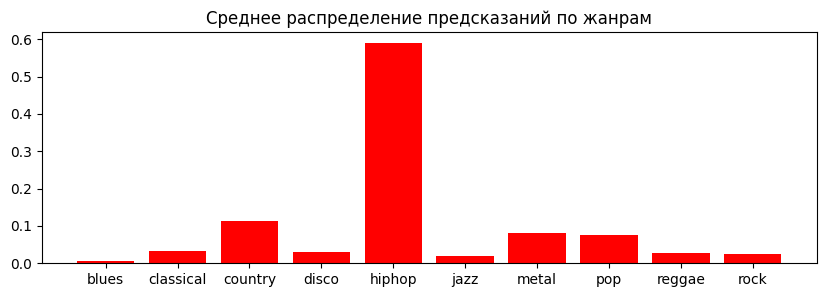

---------------------------------------------------------------
Файл: ./genres/rock/rock.00096.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: country - НЕВЕРНО.


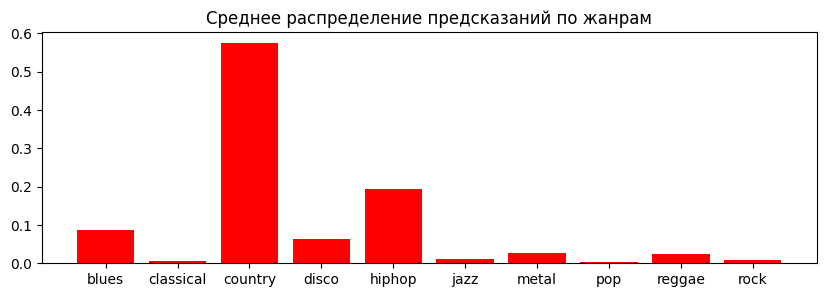

---------------------------------------------------------------
Файл: ./genres/rock/rock.00097.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: country - НЕВЕРНО.


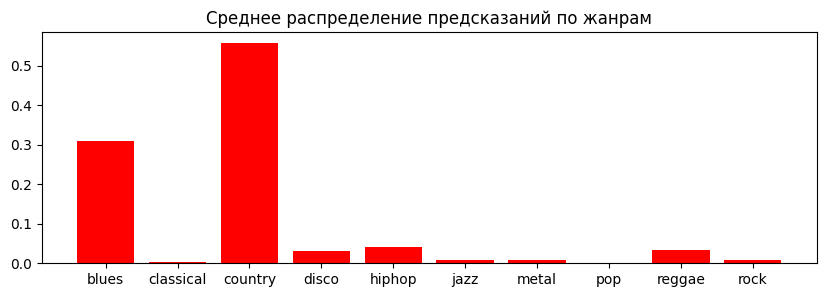

---------------------------------------------------------------
Файл: ./genres/rock/rock.00098.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: hiphop - НЕВЕРНО.


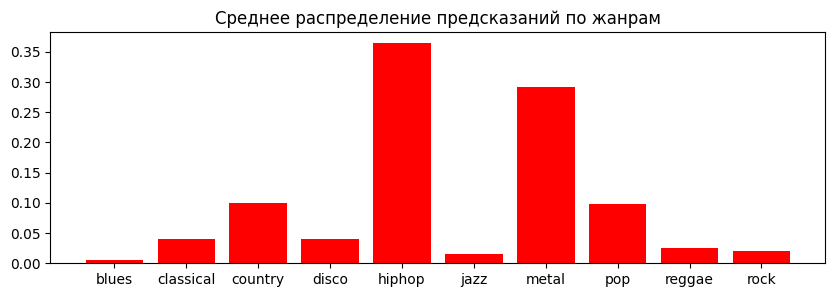

---------------------------------------------------------------
Файл: ./genres/rock/rock.00099.au
Размер массива признаков: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: hiphop - НЕВЕРНО.


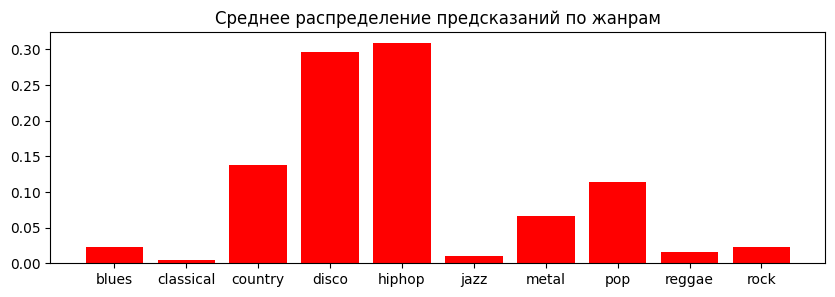

---------------------------------------------------------------
=== Проверено файлов: 100, верно распознано: 3, точность: 3.0% ===


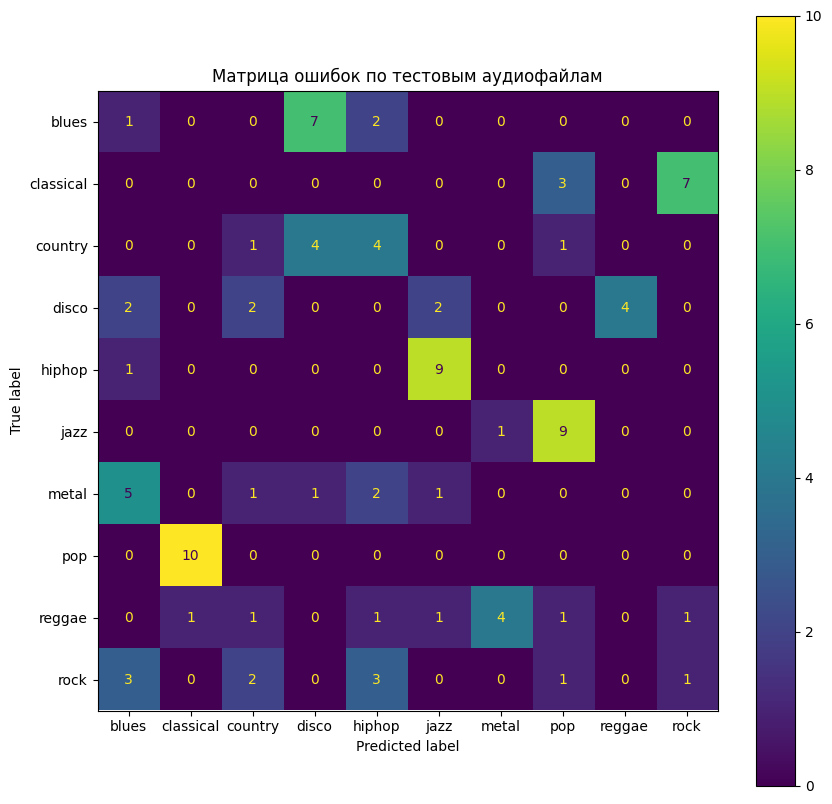

In [10]:
check_test_audio_files(
    model=model,
    x_scaler=x_scaler,
    from_index=90,
    n_files=10
)
